Leonardo Heidi Almeida Murakami, NUSP: 11260186, Undergraduate

Use of AI-generated code is NOT RECOMMENDED : However, if you have used or relied on AI, please describe which tools and how you used them

- Simple tab complete
- The whole notebook was passed through an LLM (Gemini 3.5 Flash Extended) with the prompt "Go through the whole notebook and indicate any mistakes in spelling in either english or Brazilian Portuguese and indicate them back to me but DO NOT make any changes" and gramatical changes were incorporated

# MAC0460 (2026) -- EP3: Model evaluation and selection

Dataset: Digits (8x8 images, 64 features, 10 classes)

Algorithms: SVM, Logistic Regression, Random Forest, k-NN, Decision Tree

## 1.1 First step: Train and evaluate with default hyperparameters

Get familiar with scikit-learn, specifically training and evaluating a classification algorithm. We use the **digits** dataset and a linear SVM with default hyperparameter values.

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn import datasets, svm
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

os.makedirs('images', exist_ok=True)
%matplotlib inline

In [43]:
print("=" * 60)
print("Part 1: Training")
print("=" * 60)

digits = datasets.load_digits()
X, y = digits.data, digits.target
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")

Part 1: Training
X shape: (1797, 64)
y shape: (1797,)
Number of classes: 10
Class distribution: [178 182 177 183 181 182 181 179 174 180]


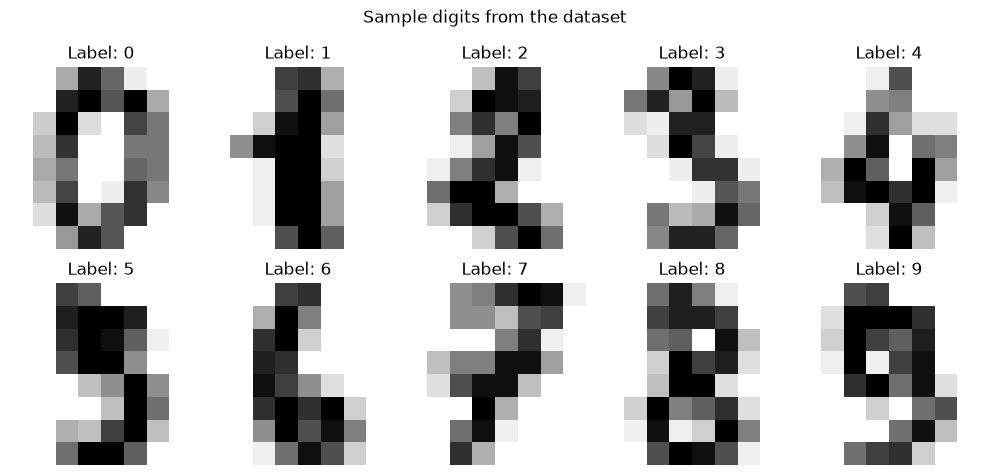

In [44]:
# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.suptitle("Sample digits from the dataset")
plt.tight_layout()
plt.savefig('images/sample_digits.png', dpi=150, bbox_inches='tight')
plt.show()

In [45]:
# Split the data (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

unique_train, counts_train = np.unique(y_train, return_counts=True)
print(f"Training set class distribution: {dict(zip(unique_train, counts_train))}")
unique_test, counts_test = np.unique(y_test, return_counts=True)
print(f"Test set class distribution: {dict(zip(unique_test, counts_test))}")


X_train shape: (1257, 64)
y_train shape: (1257,)
X_test shape: (540, 64)
y_test shape: (540,)
Training set class distribution: {np.int64(0): np.int64(124), np.int64(1): np.int64(127), np.int64(2): np.int64(124), np.int64(3): np.int64(128), np.int64(4): np.int64(127), np.int64(5): np.int64(127), np.int64(6): np.int64(127), np.int64(7): np.int64(125), np.int64(8): np.int64(122), np.int64(9): np.int64(126)}
Test set class distribution: {np.int64(0): np.int64(54), np.int64(1): np.int64(55), np.int64(2): np.int64(53), np.int64(3): np.int64(55), np.int64(4): np.int64(54), np.int64(5): np.int64(55), np.int64(6): np.int64(54), np.int64(7): np.int64(54), np.int64(8): np.int64(52), np.int64(9): np.int64(54)}


In [46]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
# Train a linear SVM with default hyperparameters
clf = svm.SVC(kernel="linear")
clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nLinear SVM (default C=1.0) -- Accuracy: {accuracy:.4f}")


Linear SVM (default C=1.0) -- Accuracy: 0.9796


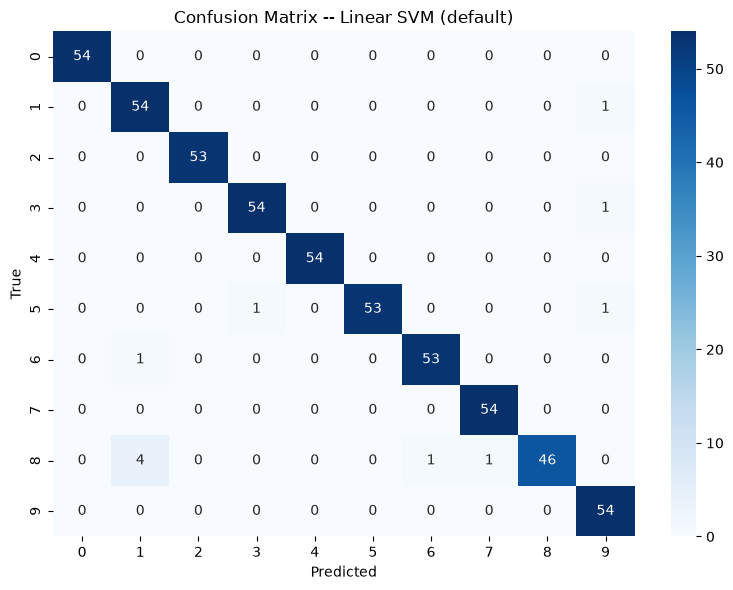

In [48]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix -- Linear SVM (default)')
plt.tight_layout()
plt.savefig('images/confusion_matrix_linear_svm_default.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.2 Third step: Grid search with scikit-learn
"Automatically" search for the best hyper-parameters to tune our model

In [49]:
print("\n" + "=" * 60)
print("Step 3: Grid search with scikit-learn")
print("=" * 60)

# Coarse grid for SVM with RBF kernel
param_grid_svm = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf']
}

print("Running coarse grid search for SVM (RBF kernel)...")
grid_svm = GridSearchCV(
    svm.SVC(), param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_svm.fit(X_train_scaled, y_train)

print(f"\nBest SVM parameters: {grid_svm.best_params_}")
print(f"Best SVM CV accuracy: {grid_svm.best_score_:.4f}")

y_pred_best_svm = grid_svm.predict(X_test_scaled)
test_acc_svm = accuracy_score(y_test, y_pred_best_svm)
print(f"SVM test accuracy (best params): {test_acc_svm:.4f}")


Step 3: Grid search with scikit-learn
Running coarse grid search for SVM (RBF kernel)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best SVM parameters: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVM CV accuracy: 0.9817
SVM test accuracy (best params): 0.9833


In [50]:
best_C = grid_svm.best_params_['C']
fine_C = np.logspace(np.log10(best_C) - 1, np.log10(best_C) + 1, 5)

param_grid_fine = {
    'C': fine_C,
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf']
}

grid_svm_fine = GridSearchCV(
    svm.SVC(), param_grid_fine, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_svm_fine.fit(X_train_scaled, y_train)

print(f"\nBest SVM (fine) parameters: {grid_svm_fine.best_params_}")
print(f"Best SVM (fine) CV accuracy: {grid_svm_fine.best_score_:.4f}")

y_pred_fine = grid_svm_fine.predict(X_test_scaled)
test_acc_fine = accuracy_score(y_test, y_pred_fine)
print(f"SVM test accuracy (fine grid): {test_acc_fine:.4f}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best SVM (fine) parameters: {'C': np.float64(3.1622776601683795), 'gamma': 'auto', 'kernel': 'rbf'}
Best SVM (fine) CV accuracy: 0.9817
SVM test accuracy (fine grid): 0.9815


# 2. Choosing between multiple algorithms

To choose a final model, we try multiple algorithms. Key considerations:

1. A separate test set is reserved for unbiased evaluation
2. Training data is split into training and validation (k-fold cross-validation)
3. The same validation split is used for all algorithms
4. The final model is chosen based on validation error

In [51]:
algorithms = {
    'SVM (RBF)': {
        'estimator': svm.SVC(kernel='rbf'),
        'param_grid': {
            'C': [0.1, 1.0, 10.0, 100.0],
            'gamma': ['scale', 0.001, 0.01, 0.1],
        }
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=42),
        'param_grid': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
        }
    },
    'k-NN': {
        'estimator': KNeighborsClassifier(),
        'param_grid': {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
        }
    },
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=42),
        'param_grid': {
            'max_depth': [None, 5, 10, 20, 50],
            'min_samples_split': [2, 5, 10],
        }
    },
}

In [52]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, config in algorithms.items():
    print(f"\n--- Tuning {name} ---")
    grid = GridSearchCV(
        config['estimator'], config['param_grid'],
        cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
    )
    grid.fit(X_train_scaled, y_train)

    cv_mean = grid.best_score_
    cv_std = grid.cv_results_['std_test_score'][grid.best_index_]

    y_pred = grid.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)

    results[name] = {
        'best_params': grid.best_params_,
        'cv_accuracy': cv_mean,
        'cv_std': cv_std,
        'test_accuracy': test_acc,
        'y_pred': y_pred,
    }

    print(f"  Best params: {grid.best_params_}")
    print(f"  CV accuracy: {cv_mean:.4f} (+/- {cv_std:.4f})")
    print(f"  Test accuracy: {test_acc:.4f}")


--- Tuning SVM (RBF) ---
  Best params: {'C': 10.0, 'gamma': 0.01}
  CV accuracy: 0.9801 (+/- 0.0084)
  Test accuracy: 0.9815

--- Tuning Random Forest ---
  Best params: {'max_depth': None, 'n_estimators': 200}
  CV accuracy: 0.9737 (+/- 0.0054)
  Test accuracy: 0.9667

--- Tuning k-NN ---
  Best params: {'n_neighbors': 5, 'weights': 'distance'}
  CV accuracy: 0.9682 (+/- 0.0056)
  Test accuracy: 0.9722

--- Tuning Decision Tree ---
  Best params: {'max_depth': 10, 'min_samples_split': 2}
  CV accuracy: 0.8497 (+/- 0.0298)
  Test accuracy: 0.8574


In [53]:
print("\n" + "=" * 60)
print("Summary: Algorithm comparison")
print("=" * 60)
print(f"{'Algorithm':<25} {'CV Accuracy':>12} {'CV Std':>8} {'Test Accuracy':>14}")
print("-" * 62)
for name, r in sorted(results.items(), key=lambda x: -x[1]['cv_accuracy']):
    print(f"{name:<25} {r['cv_accuracy']:>12.4f} {r['cv_std']:>8.4f} {r['test_accuracy']:>14.4f}")


Summary: Algorithm comparison
Algorithm                  CV Accuracy   CV Std  Test Accuracy
--------------------------------------------------------------
SVM (RBF)                       0.9801   0.0084         0.9815
Random Forest                   0.9737   0.0054         0.9667
k-NN                            0.9682   0.0056         0.9722
Decision Tree                   0.8497   0.0298         0.8574


- **Por que o SVM foi melhor?** O SVM funciona muito bem com muitas dimensões (64 atributos). O uso do kernel RBF permitiu criar regras de separação mais complexas e eficientes do que os outros métodos.
- **Por que a Árvore de Decisão foi pior?** Árvores de decisão sozinhas sofrem muito com *overfitting*. Elas mudam muito com qualquer pequena variação nos dados. O Random Forest corrigiu isso criando várias árvores juntas.
- **Validação Cruzada vs. Teste:** As acurácias de validação e de teste ficaram muito próximas. Isso prova que o processo foi bem feito e que o modelo não sofreu *overfitting* na escolha dos parâmetros. Se usássemos o teste para escolher os parâmetros, o resultado seria enviesado.
- **Importância de Padronizar:** O SVM e o $k$-NN calculam distâncias entre os pontos. Se os pixels não estivessem na mesma escala, os atributos com números maiores iam distorcer todo o cálculo do modelo.

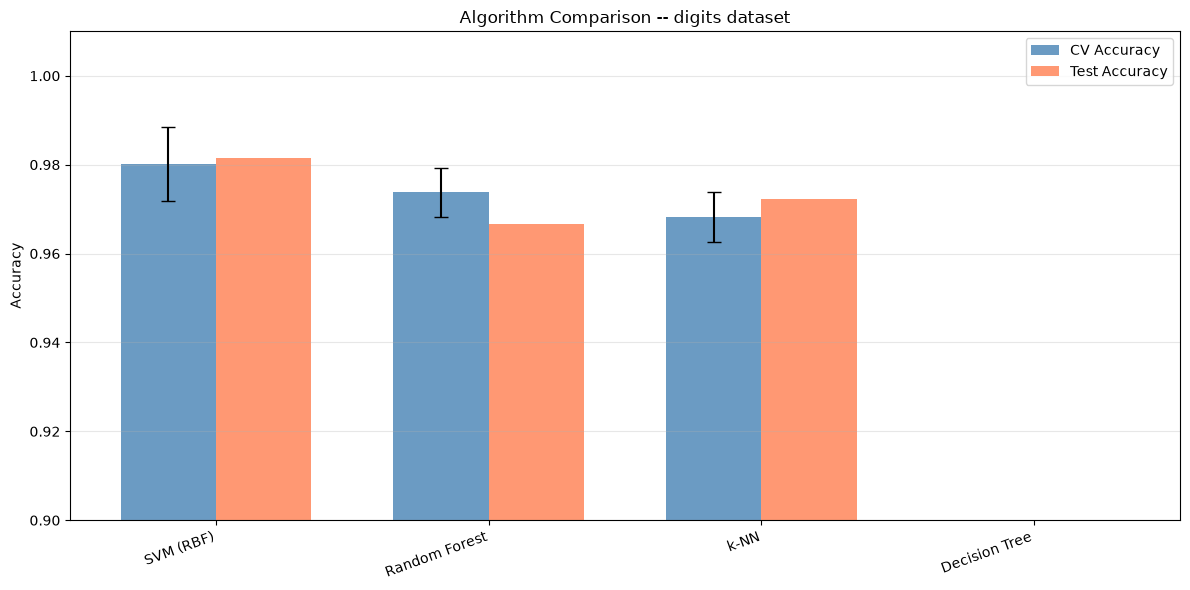

In [54]:
names = list(results.keys())
cv_accs = [results[n]['cv_accuracy'] for n in names]
cv_stds = [results[n]['cv_std'] for n in names]
test_accs = [results[n]['test_accuracy'] for n in names]

x_pos = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x_pos - width/2, cv_accs, width, yerr=cv_stds, label='CV Accuracy',
       capsize=5, color='steelblue', alpha=0.8)
ax.bar(x_pos + width/2, test_accs, width, label='Test Accuracy',
       color='coral', alpha=0.8)
ax.set_ylabel('Accuracy')
ax.set_title('Algorithm Comparison -- digits dataset')
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.9, 1.01)
plt.tight_layout()
plt.savefig('images/algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Best model: SVM (RBF)
  CV accuracy: 0.9801
  Test accuracy: 0.9815
  Parameters: {'C': 10.0, 'gamma': 0.01}

Classification report (SVM (RBF)):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      0.98      0.96        55
           2       1.00      0.98      0.99        53
           3       1.00      1.00      1.00        55
           4       0.95      0.98      0.96        54
           5       1.00      0.98      0.99        55
           6       0.98      1.00      0.99        54
           7       0.96      1.00      0.98        54
           8       1.00      0.92      0.96        52
           9       0.98      0.96      0.97        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



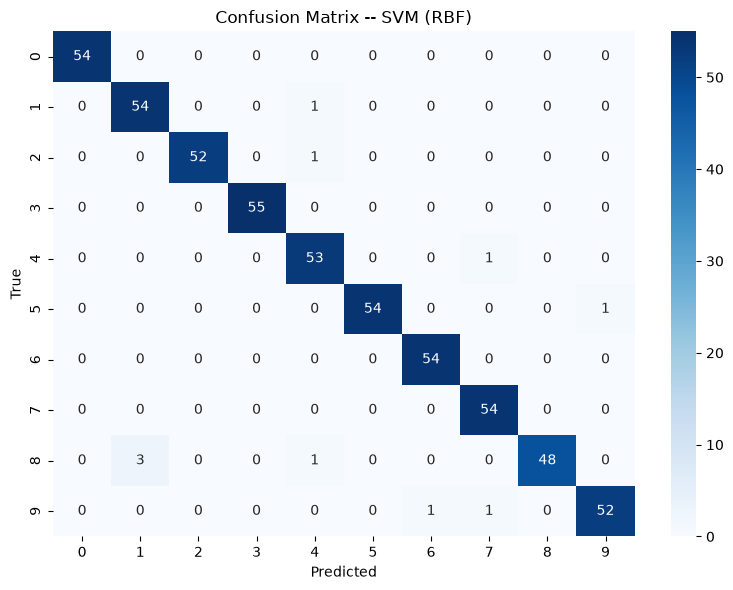

In [55]:
best_model_name = max(results, key=lambda k: results[k]['cv_accuracy'])
print(f"\n{'=' * 60}")
print(f"Best model: {best_model_name}")
print(f"  CV accuracy: {results[best_model_name]['cv_accuracy']:.4f}")
print(f"  Test accuracy: {results[best_model_name]['test_accuracy']:.4f}")
print(f"  Parameters: {results[best_model_name]['best_params']}")
print(f"{'=' * 60}")

print(f"\nClassification report ({best_model_name}):")
print(classification_report(y_test, results[best_model_name]['y_pred'],
                            target_names=[str(d) for d in digits.target_names]))

cm_best = confusion_matrix(y_test, results[best_model_name]['y_pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix -- {best_model_name}')
plt.tight_layout()
plt.savefig('images/confusion_matrix_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

# Misclassified Data

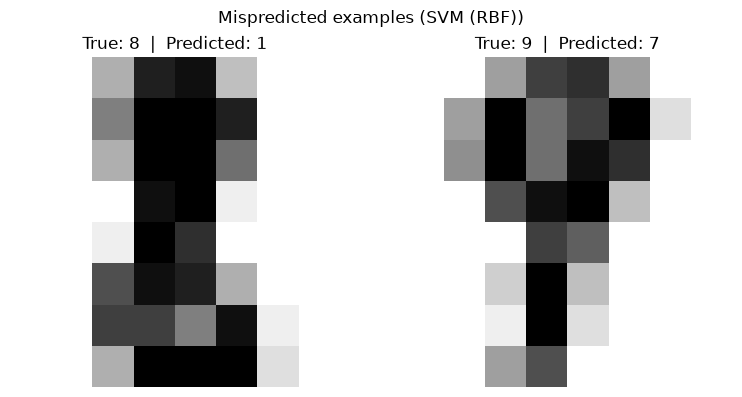

In [58]:
misclassified = np.where(y_test != results[best_model_name]['y_pred'])[0]
chosen = np.random.choice(misclassified, size=2, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, idx in zip(axes, chosen):
    ax.imshow(X_test[idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f"True: {y_test[idx]}  |  Predicted: {results[best_model_name]['y_pred'][idx]}")
    ax.axis('off')
plt.suptitle(f"Mispredicted examples ({best_model_name})")
plt.tight_layout()
plt.savefig('images/mispredicted_examples.png', dpi=150, bbox_inches='tight')
plt.show()

Ambos os erros são totalmente compreensíveis. Sem olhar o rótulo com a resposta, até para mim é difícil identificar que números são esses.